In [12]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Loading the dataset
df = pd.read_csv('Sample - Superstore.csv', encoding='Latin1')

# See first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [14]:
# How many rows and columns do we have?
print("Shape:", df.shape)

# What are all the column names?
print("\nColumns:", df.columns.tolist())

# What type of data is in each column?
print("\nData Types:\n", df.dtypes)

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:
 Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [15]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [16]:
# Fix date columns - convert from text to actual dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Confirm the fix worked
print("Updated Data Types:")
print(df['Order Date'].dtype)
print(df['Ship Date'].dtype)

Updated Data Types:
datetime64[us]
datetime64[us]


In [17]:
# Total sales by category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("Sales by Category:\n", category_sales)

Sales by Category:
 Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


In [18]:
# Total profit by region
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print("Profit by Region:\n", region_profit)

Profit by Region:
 Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


In [19]:
# Extract month and year from Order Date
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

# Total sales by year and month
monthly_sales = df.groupby(['Year' , 'Month'])['Sales'].sum()
print("Monthly Sales Trend:\n", monthly_sales)

Monthly Sales Trend:
 Year  Month
2014  1         14236.8950
      2          4519.8920
      3         55691.0090
      4         28295.3450
      5         23648.2870
      6         34595.1276
      7         33946.3930
      8         27909.4685
      9         81777.3508
      10        31453.3930
      11        78628.7167
      12        69545.6205
2015  1         18174.0756
      2         11951.4110
      3         38726.2520
      4         34195.2085
      5         30131.6865
      6         24797.2920
      7         28765.3250
      8         36898.3322
      9         64595.9180
      10        31404.9235
      11        75972.5635
      12        74919.5212
2016  1         18542.4910
      2         22978.8150
      3         51715.8750
      4         38750.0390
      5         56987.7280
      6         40344.5340
      7         39261.9630
      8         31115.3743
      9         73410.0249
      10        59687.7450
      11        79411.9658
      12        96999

In [20]:
# Profit by customer segment
segment_profit = df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)
print("Profit by Segment:\n", segment_profit)

Profit by Segment:
 Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64


In [21]:
# Top 10 products by sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print("Top 10 Products:\n", top_products)

Top 10 Products:
 Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [23]:
# Setting up Chart style
plt.style.use('ggplot')
sns.set_palette("husl")

print("Chart style set! ✅")

Chart style set! ✅


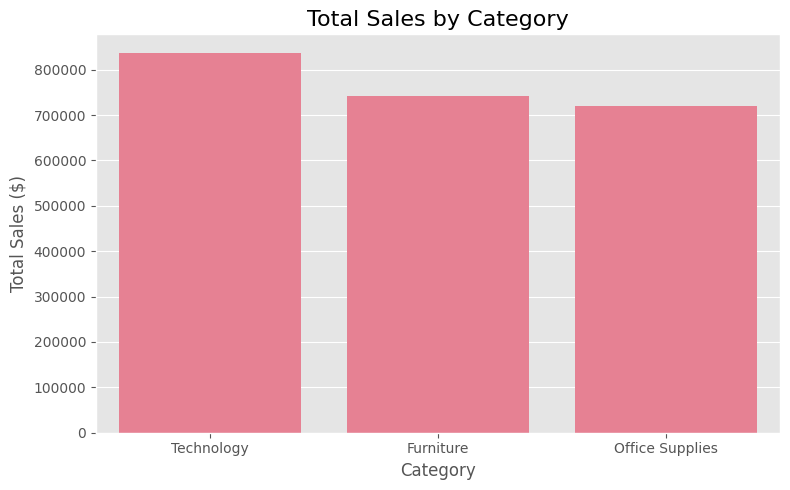

Chart 1 saved! ✅


In [27]:
# Chart 1 - Sales by Category
plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title('Total Sales by Category', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('chart1_category_sales.png')
plt.show()
print("Chart 1 saved! ✅")

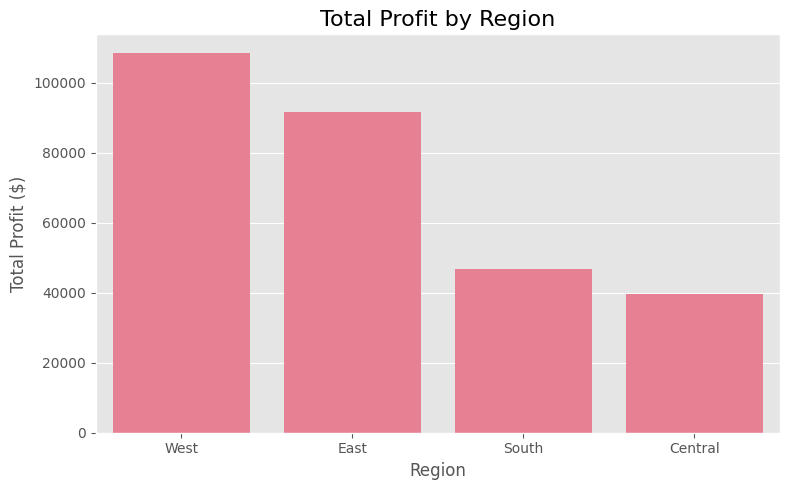

Chart 2 saved! ✅


In [28]:
# Chart 2 - Profit by Region
plt.figure(figsize=(8, 5))
sns.barplot(x=region_profit.index, y=region_profit.values)
plt.title('Total Profit by Region', fontsize=16)
plt.xlabel('Region')
plt.ylabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('chart2_region_profit.png')
plt.show()
print("Chart 2 saved! ✅")

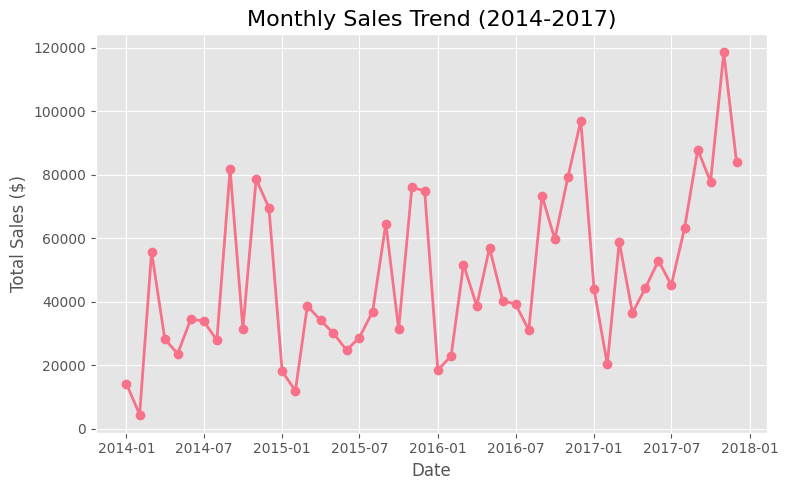

Chart 3 saved! ✅


In [29]:
# Chart 3 - Monthly Sales Trend
monthly_sales_reset = monthly_sales.reset_index()
monthly_sales_reset['Date'] = pd.to_datetime(monthly_sales_reset[['Year', 'Month']].assign(day=1))

plt.figure(figsize=(8, 5))
plt.plot(monthly_sales_reset['Date'], monthly_sales_reset['Sales'], marker='o', linewidth=2)
plt.title('Monthly Sales Trend (2014-2017)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('chart3_monthly_trend.png')
plt.show()
print("Chart 3 saved! ✅")

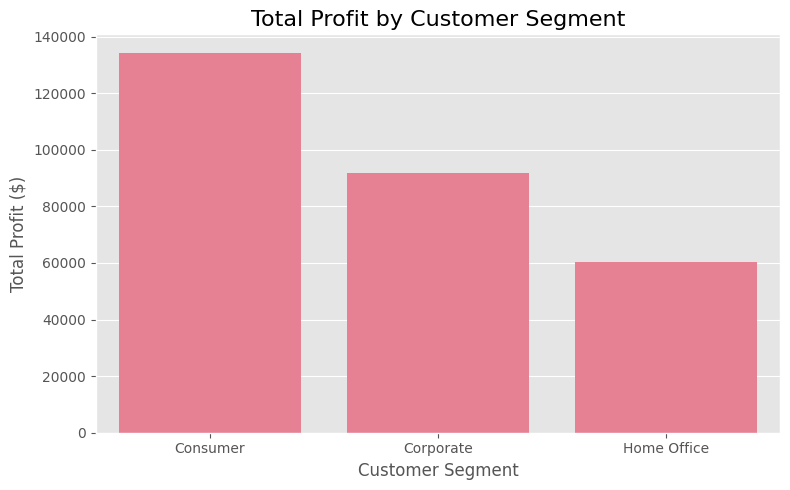

Chart 4 saved! ✅


In [30]:
# Chart 4 - Profit by Customer Segment
plt.figure(figsize=(8, 5))
sns.barplot(x=segment_profit.index, y=segment_profit.values)
plt.title('Total Profit by Customer Segment', fontsize=16)
plt.xlabel('Customer Segment')
plt.ylabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('chart4_segment_profit.png')
plt.show()
print("Chart 4 saved! ✅")

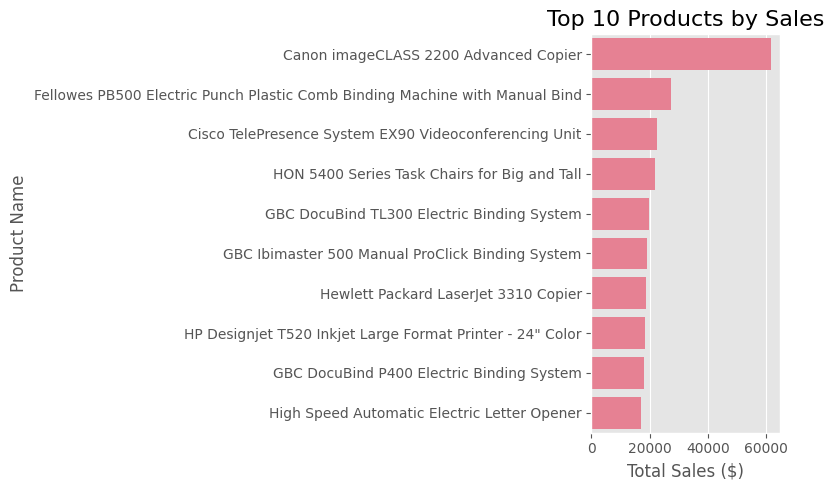

Chart 5 saved! ✅


In [31]:
# Chart 5 - Top 10 Products
plt.figure(figsize=(8, 5))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('Top 10 Products by Sales', fontsize=16)
plt.xlabel('Total Sales ($)')
plt.ylabel('Product Name')
plt.tight_layout()
plt.savefig('chart5_top_products.png')
plt.show()
print("Chart 5 saved! ✅")

# 🛒 Superstore Sales Analysis Project

## Overview
This project analyzes **9,994 sales records** from a US retail superstore 
covering the years 2014-2017. The goal is to identify key trends, 
top performing products, and actionable business insights using Python.

## Tools Used
- **Python** (Pandas, Matplotlib, Seaborn)
- **Dataset:** Superstore Sales Dataset (Kaggle)
- **Environment:** VS Code + Jupyter Notebook

## 📊 Key Business Insights

### Insight 1 — Category Performance
Technology is the highest selling category with **$836,154 in total sales**,
outperforming Furniture ($741,999) and Office Supplies ($719,047).
The business should prioritize Technology inventory and marketing.

### Insight 2 — Regional Profitability
The **West region is the most profitable** generating $108,418 in profit —
nearly 3x more than the Central region ($39,706).
The Central region needs immediate attention to improve profitability.

### Insight 3 — Sales Trend
Sales show a **consistent upward growth trend from 2014 to 2017**.
Peak monthly sales grew from $82,000 in 2014 to $118,000 in 2017.
Sales spike every November-December due to holiday season demand.

### Insight 4 — Customer Segments
The **Consumer segment is the most profitable** with $134,119 in profit,
more than double the Home Office segment ($60,298).
Marketing efforts should focus primarily on Consumer segment customers.

### Insight 5 — Top Products
**Canon imageCLASS 2200 Advanced Copier** is the #1 best selling product
with $61,599 in sales — more than double the 2nd ranked product.
Technology products dominate the top 10 best sellers list.

## ✅ Conclusion & Recommendations

Based on the analysis of 9,994 sales records from 2014-2017:

1. **Invest more in Technology** — highest revenue category at $836K
2. **Focus on West & East regions** — contribute 85% of total profit
3. **Prepare for November-December** — stock up before holiday season spikes
4. **Prioritize Consumer segment** — most profitable customer group
5. **Promote Canon & Fellowes products** — top revenue generating products

## 🛠️ Technical Skills Demonstrated
- Data loading and exploration with **Pandas**
- Data cleaning — fixing data types and handling date columns
- Exploratory Data Analysis **(EDA)** using groupby and aggregations
- Data visualization using **Matplotlib** and **Seaborn**
- Business insight generation from raw data